<a href="https://colab.research.google.com/github/Goutam-A-B/Cardiac-Chamber-Volume-Estimation-from-MRI-Images-using-Deep-Neural-Networks/blob/main/23MAI0038_Multi_Label_Classification_of_Images_using_Swin_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -Uq transformers datasets timm accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 19.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as T
import datasets
import evaluate

In [ ]:
from pathlib import Path
from PIL import Image
from transformers.optimization import get_cosine_schedule_with_warmup
from timm import list_models, create_model
from accelerate import Accelerator, notebook_launcher

In [ ]:
dataset = datasets.load_dataset('fuliucansheng/pascal_voc','voc2007_main')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pascal_voc.py:   0%|          | 0.00/15.2k [00:00<?, ?B/s]

The repository for fuliucansheng/pascal_voc contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/fuliucansheng/pascal_voc.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


voc2007.tar.gz:   0%|          | 0.00/878M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'image', 'height', 'width', 'classes', 'objects'],
        num_rows: 2501
    })
    validation: Dataset({
        features: ['id', 'image', 'height', 'width', 'classes', 'objects'],
        num_rows: 2510
    })
    test: Dataset({
        features: ['id', 'image', 'height', 'width', 'classes', 'objects'],
        num_rows: 4952
    })
})

In [ ]:
class_names = [
    "Aeroplane","Bicycle","Bird","Boat","Bottle",
    "Bus","Car","Cat","Chair","Cow","Diningtable",
    "Dog","Horse","Motorbike","Person",
    "Potted plant","Sheep","Sofa","Train","Tv/monitor"
]

In [ ]:
label2id = {c:idx for idx,c in enumerate(class_names)}
id2label = {idx:c for idx,c in enumerate(class_names)}

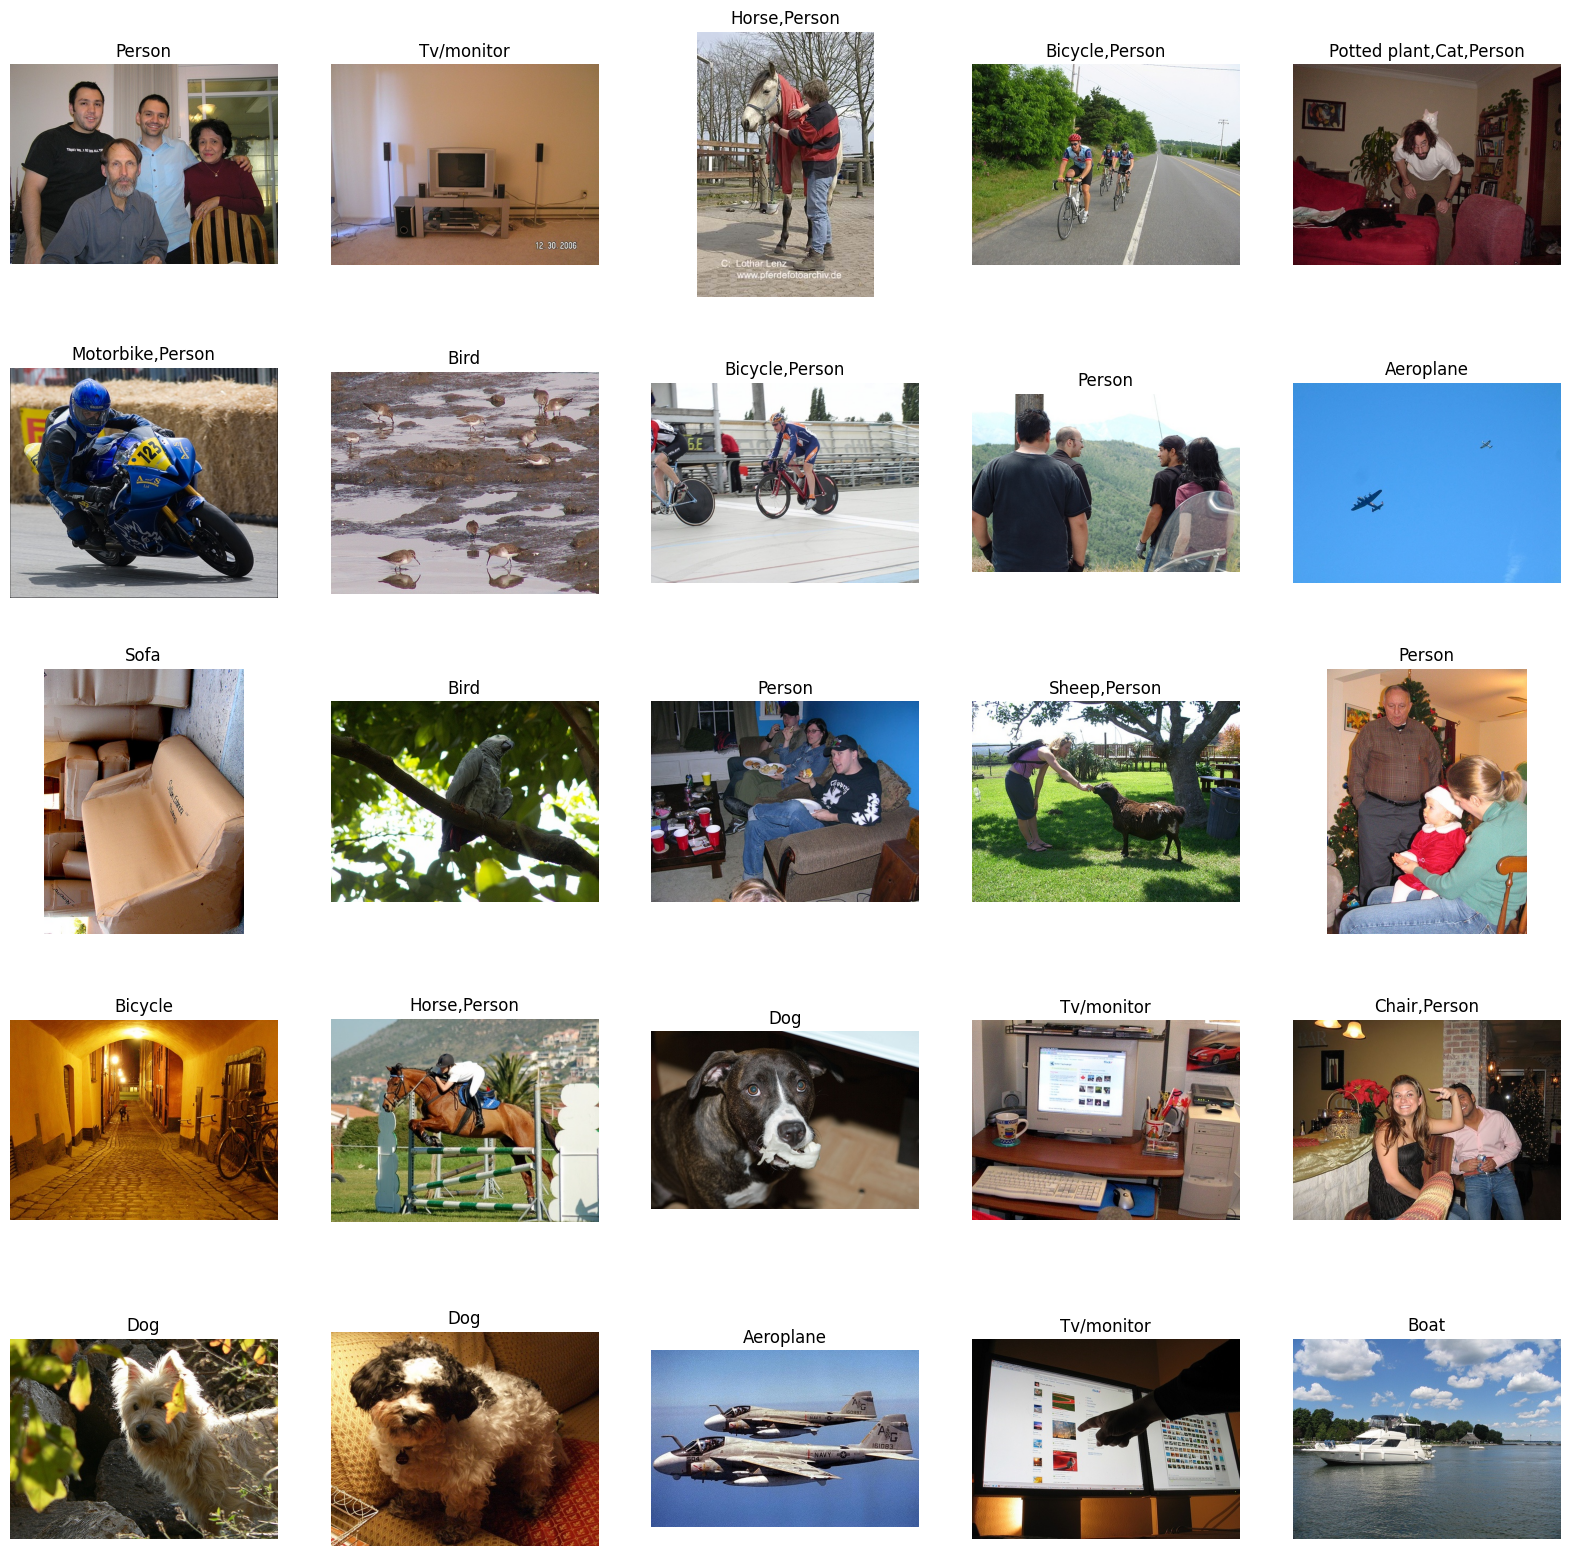

In [ ]:
def show_samples(ds,rows,cols):
    samples = ds.shuffle().select(np.arange(rows*cols)) # selecting random images
    fig = plt.figure(figsize=(cols*4,rows*4))
    # plotting
    for i in range(rows*cols):
        img = samples[i]['image']
        labels = samples[i]['classes']
        # getting string labels and combining them with a comma
        labels = ','.join([id2label[lb] for lb in labels])
        fig.add_subplot(rows,cols,i+1)
        plt.imshow(img)
        plt.title(labels)
        plt.axis('off')

show_samples(dataset['train'],rows=5,cols=5)

In [ ]:
img_size = (224,224)

train_tfms = T.Compose([
    T.Resize(img_size),
    T.RandomHorizontalFlip(),
    T.RandomRotation(30),
    T.CenterCrop(img_size),
    T.ToTensor(),
    T.Normalize(
        mean = (0.5,0.5,0.5),
         std = (0.5,0.5,0.5)
    )
])

valid_tfms = T.Compose([
    T.Resize(img_size),
    T.ToTensor(),
    T.Normalize(
        mean = (0.5,0.5,0.5),
         std = (0.5,0.5,0.5)
    )
])

In [ ]:
import torch
import torch.nn as nn

def train_transforms(batch):
    # Convert all images in batch to RGB to avoid grayscale or transparent images
    batch['image'] = [x.convert('RGB') for x in batch['image']]
    # Apply torchvision.transforms per sample in the batch
    inputs = [train_tfms(x) for x in batch['image']]
    batch['pixel_values'] = inputs

    # One-hot encoding the labels
    labels = torch.zeros((len(batch['classes']), 20))
    for i, classes in enumerate(batch['classes']):
        labels[i, classes] = 1
    batch['labels'] = labels

    return batch

def valid_transforms(batch):
    # Convert all images in batch to RGB to avoid grayscale or transparent images
    batch['image'] = [x.convert('RGB') for x in batch['image']]
    # Apply torchvision.transforms per sample in the batch
    inputs = [valid_tfms(x) for x in batch['image']]
    batch['pixel_values'] = inputs

    # One-hot encoding the labels
    labels = torch.zeros((len(batch['classes']), 20))
    for i, classes in enumerate(batch['classes']):
        labels[i, classes] = 1
    batch['labels'] = labels

    return batch

In [ ]:
train_dataset = dataset['train'].with_transform(train_transforms)
valid_dataset = dataset['validation'].with_transform(valid_transforms)
test_dataset = dataset['test'].with_transform(valid_transforms)

len(train_dataset), len(valid_dataset), len(test_dataset)

(2501, 2510, 4952)

In [ ]:
def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch]).float()
    }

In [ ]:
def param_count(model):
    params = [(p.numel(),p.requires_grad) for p in model.parameters()]
    trainable = sum([count for count,trainable in params if trainable])
    total = sum([count for count,_ in params])
    frac = (trainable / total) * 100
    return total, trainable, frac

**Import Dependencies**

In [ ]:
import torch
import numpy as np
from accelerate import Accelerator
import torch.nn as nn
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import evaluate
from timm import create_model
from transformers import get_cosine_schedule_with_warmup

In [ ]:
def train(model_name, batch_size=16, epochs=1, lr=2e-4):
    """
    Training, validation, and testing loops with confusion matrix, overall accuracy,
    learning rate after each epoch, and metrics for research paper purposes.
    """
    accelerator = Accelerator()

    # Define dataloaders
    train_dl = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    valid_dl = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size*2, shuffle=False, collate_fn=collate_fn)
    test_dl = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size*2, shuffle=False, collate_fn=collate_fn)

    model = create_model(model_name, pretrained=True, num_classes=20).to(accelerator.device)

    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.02)

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * len(train_dl)),
        num_training_steps=len(train_dl)
    )

    model, optimizer, scheduler, train_dl, valid_dl, test_dl = accelerator.prepare(model, optimizer, scheduler, train_dl, valid_dl, test_dl)

    train_losses, valid_losses, train_roc_aucs, valid_roc_aucs, lrs = [], [], [], [], []

    for epoch in range(1, epochs+1):
        model.train()
        train_metric = evaluate.load('roc_auc', 'multilabel')

        running_loss = 0.
        for batch in train_dl:
            logits = model(batch['pixel_values'])
            loss = loss_fn(logits, batch['labels'])
            accelerator.backward(loss)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            running_loss += loss.item()

            logits, labels = accelerator.gather_for_metrics((logits, batch['labels']))
            train_metric.add_batch(references=labels, prediction_scores=logits)

        train_loss = running_loss / len(train_dl)
        train_roc_auc = train_metric.compute(average='micro')['roc_auc']

        # Store the last learning rate after each epoch
        last_lr = optimizer.param_groups[0]['lr']

        accelerator.print(f"\n{epoch = }")
        accelerator.print(f"{train_loss = :.3f} | {train_roc_auc = :.3f} | Last LR = {last_lr:.6f}")

        # Append training data for plotting
        train_losses.append(train_loss)
        train_roc_aucs.append(train_roc_auc)
        lrs.append(last_lr)

        # Validation loop
        model.eval()
        running_loss = 0.
        valid_metric = evaluate.load('roc_auc', 'multilabel')
        for batch in valid_dl:
            with torch.no_grad():
                logits = model(batch['pixel_values'])
            loss = loss_fn(logits, batch['labels'])
            running_loss += loss.item()

            logits, labels = accelerator.gather_for_metrics((logits, batch['labels']))
            valid_metric.add_batch(references=labels, prediction_scores=logits)

        valid_loss = running_loss / len(valid_dl)
        valid_roc_auc = valid_metric.compute(average='micro')['roc_auc']

        accelerator.print(f"{valid_loss = :.3f} | {valid_roc_auc = :.3f}")

        # Append validation data for plotting
        valid_losses.append(valid_loss)
        valid_roc_aucs.append(valid_roc_auc)

        accelerator.save_model(model, f'./{model_name}-pascal')

    # Testing loop after all epochs
    test_metric = evaluate.load('roc_auc', 'multilabel')
    all_labels, all_predictions = [], []

    for batch in test_dl:
        with torch.no_grad():
            logits = model(batch['pixel_values'])

        logits, labels = accelerator.gather_for_metrics((logits, batch['labels']))
        test_metric.add_batch(references=labels, prediction_scores=logits)

        # Convert logits to predictions (binary, multi-label)
        predictions = (logits.sigmoid() > 0.5).float()
        all_labels.append(labels.cpu().numpy())
        all_predictions.append(predictions.cpu().numpy())

    test_roc_auc = test_metric.compute(average='micro')['roc_auc']
    accelerator.print(f"\n\nTEST AUROC: {test_roc_auc:.3f}")

    # Concatenate all collected labels and predictions
    all_labels = np.concatenate(all_labels, axis=0)
    all_predictions = np.concatenate(all_predictions, axis=0)

    # Confusion Matrix & Overall Accuracy
    overall_acc = accuracy_score(all_labels.flatten(), all_predictions.flatten())
    conf_matrix = confusion_matrix(all_labels.flatten(), all_predictions.flatten())
    precision = precision_score(all_labels.flatten(), all_predictions.flatten(), average='micro')
    recall = recall_score(all_labels.flatten(), all_predictions.flatten(), average='micro')

    # Print overall metrics for research paper
    print("\n====== Overall Metrics ======")
    print(f"Overall Accuracy: {overall_acc:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"Test ROC-AUC: {test_roc_auc:.3f}")
    print("Confusion Matrix:")
    print(conf_matrix)

    # Plotting all the metrics
    plot_metrics(epochs, train_losses, valid_losses, train_roc_aucs, valid_roc_aucs, lrs)


In [ ]:
def plot_metrics(epochs, train_losses, valid_losses, train_roc_aucs, valid_roc_aucs, lrs):
    fig, axs = plt.subplots(3, 1, figsize=(10, 15))

    # Loss Plot
    axs[0].plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
    axs[0].plot(range(1, epochs+1), valid_losses, label='Validation Loss', marker='o')
    axs[0].set_title('Train and Validation Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axs[0].legend()
    axs[0].grid(True)

    # ROC-AUC Plot
    axs[1].plot(range(1, epochs+1), train_roc_aucs, label='Train ROC-AUC', marker='o')
    axs[1].plot(range(1, epochs+1), valid_roc_aucs, label='Validation ROC-AUC', marker='o')
    axs[1].set_title('Train and Validation ROC-AUC')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('ROC-AUC')
    axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    axs[1].legend()
    axs[1].grid(True)

    # Learning Rate Plot
    axs[2].plot(range(1, epochs+1), lrs, label='Learning Rate', marker='o')
    axs[2].set_title('Learning Rate over Epochs')
    axs[2].set_xlabel('Epochs')
    axs[2].set_ylabel('Learning Rate')
    axs[2].xaxis.set_major_locator(MaxNLocator(integer=True))
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()


Launching training on one GPU.


model.safetensors:   0%|          | 0.00/295M [00:00<?, ?B/s]


epoch = 1
train_loss = 0.174 | train_roc_auc = 0.900 | Last LR = 0.000000
valid_loss = 0.088 | valid_roc_auc = 0.983

epoch = 2
train_loss = 0.080 | train_roc_auc = 0.983 | Last LR = 0.000049
valid_loss = 0.064 | valid_roc_auc = 0.987

epoch = 3
train_loss = 0.048 | train_roc_auc = 0.993 | Last LR = 0.000006
valid_loss = 0.050 | valid_roc_auc = 0.992

epoch = 4
train_loss = 0.042 | train_roc_auc = 0.995 | Last LR = 0.000038
valid_loss = 0.057 | valid_roc_auc = 0.989

epoch = 5
train_loss = 0.028 | train_roc_auc = 0.998 | Last LR = 0.000020
valid_loss = 0.046 | valid_roc_auc = 0.993


TEST AUROC: 0.992

====== Overall Metrics ======
Overall Accuracy: 0.985
Precision: 0.985
Recall: 0.985
Test ROC-AUC: 0.992
Confusion Matrix:
[[91426   601]
 [  931  6082]]


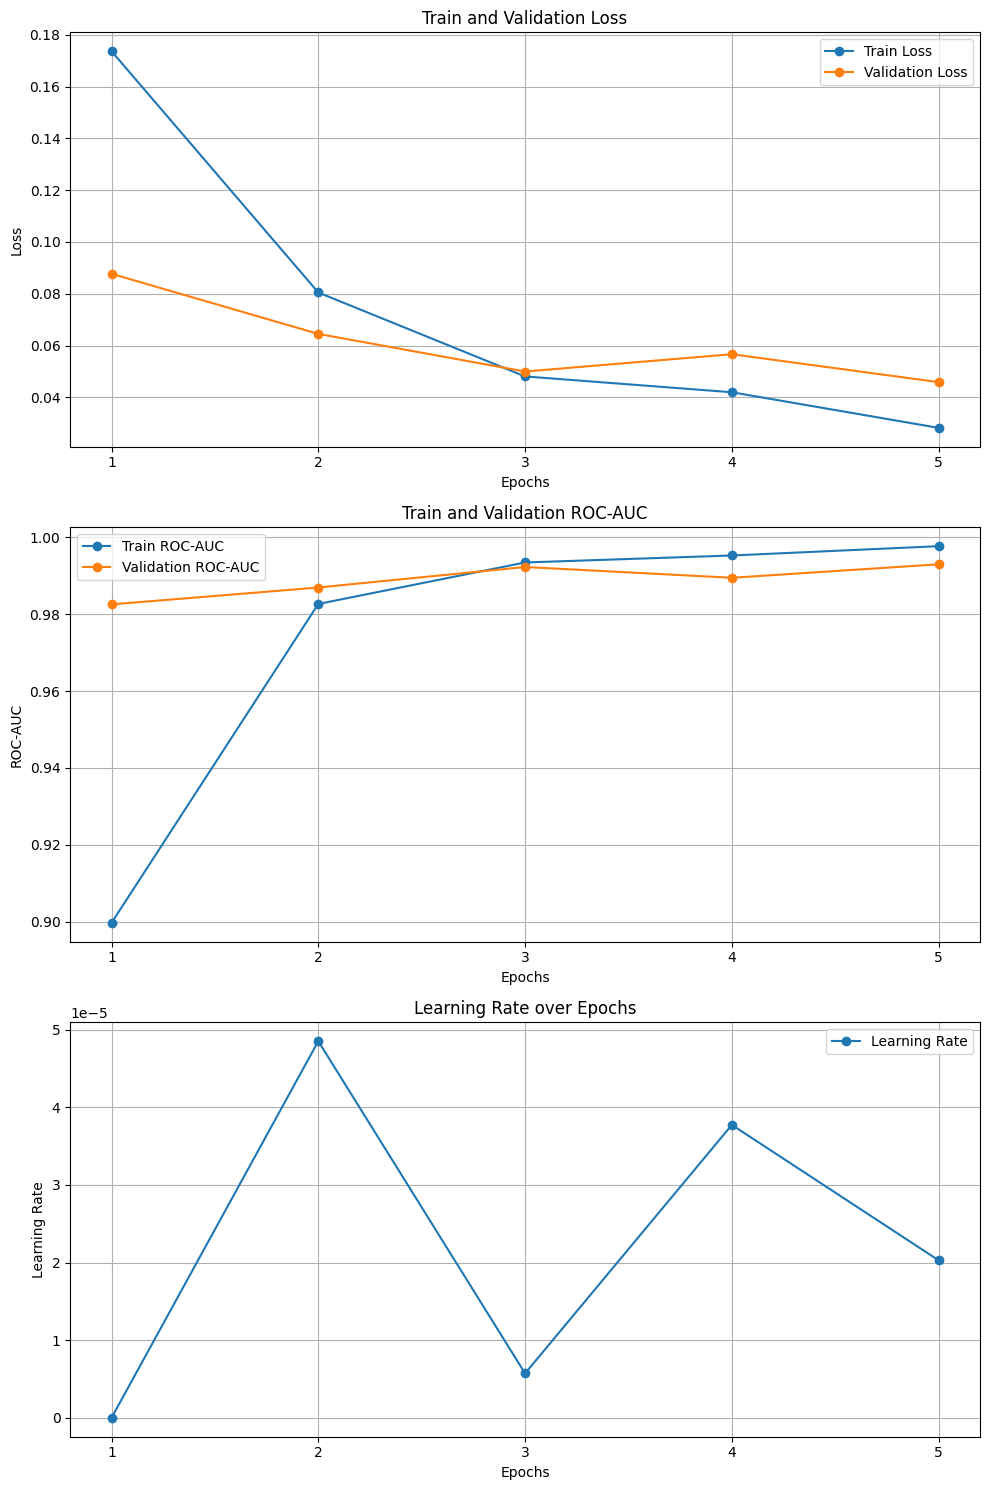

In [ ]:
# Launching the training with the new visualizations and metrics
model_name = 'swin_s3_base_224'
notebook_launcher(train, (model_name, 8, 5, 5e-5))


In [ ]:
# intialize the model

model = create_model(
    model_name,
    num_classes=20
)

In [ ]:
from safetensors.torch import load_model

In [ ]:
load_model(model,f'./{model_name}-pascal/model.safetensors')

(set(), [])

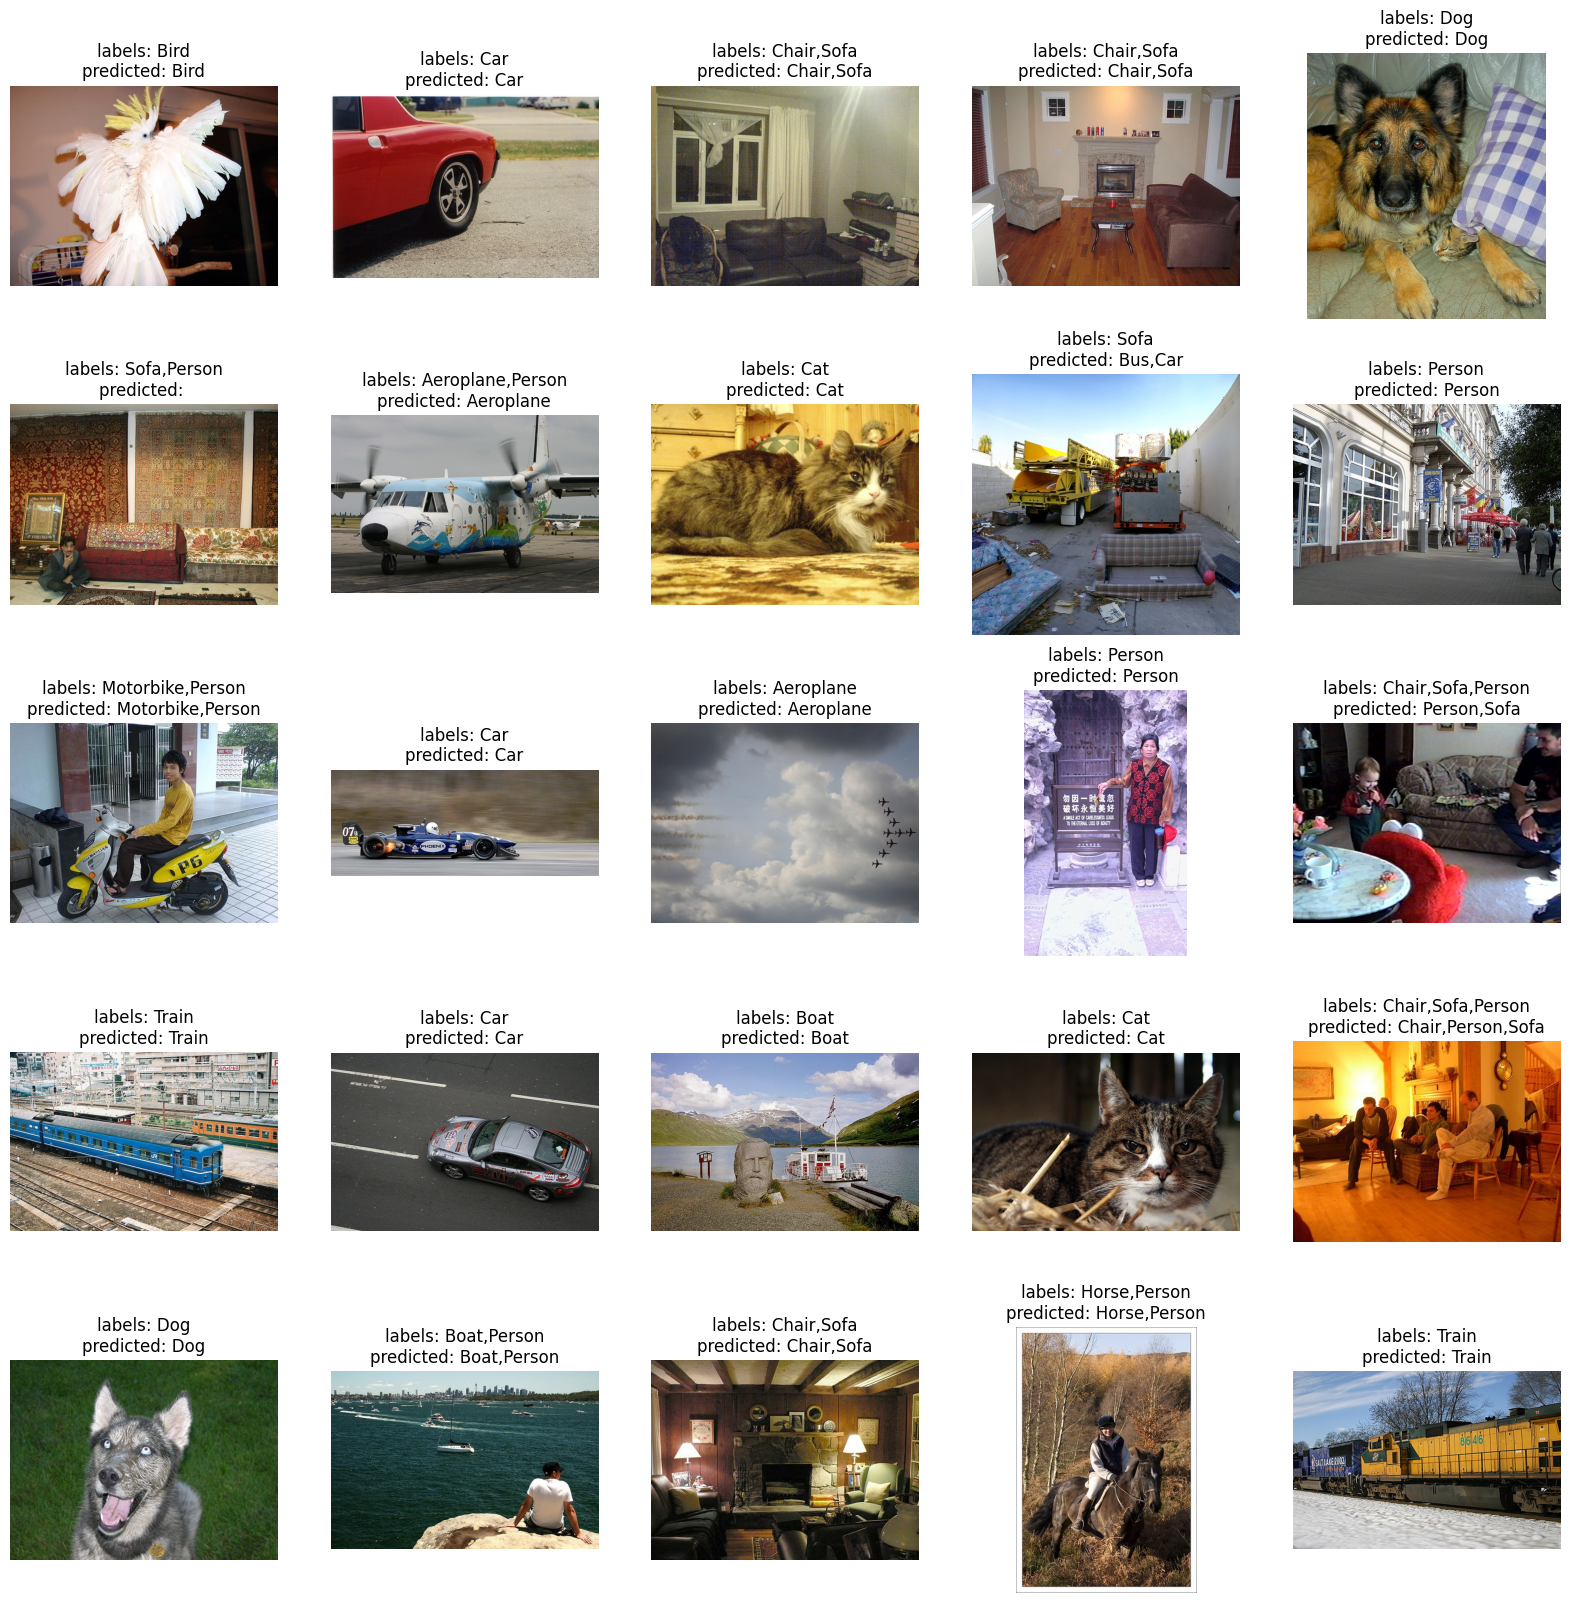

In [ ]:
def show_predictions(rows=2,cols=4):
    model.eval()
    samples = test_dataset.shuffle().select(np.arange(rows*cols))
    fig = plt.figure(figsize=(cols*4,rows*4))

    for i in range(rows*cols):

        img = samples[i]['image']
        inputs = samples[i]['pixel_values'].unsqueeze(0)
        labels = samples[i]['classes']
        labels = ','.join([id2label[lb] for lb in labels])

        with torch.no_grad():
            logits = model(inputs)

        # apply sigmoid activation to convert logits to probabilities
        # getting labels with confidence threshold of 0.5
        predictions = logits.sigmoid() > 0.5

        # converting one-hot encoded predictions back to list of labels
        predictions = predictions.float().numpy().flatten() # convert boolean predictions to float
        pred_labels = np.where(predictions==1)[0] # find indices where prediction is 1
        pred_labels = ','.join([id2label[label] for label in pred_labels]) # converting integer labels to string

        label = f"labels: {labels}\npredicted: {pred_labels}"
        fig.add_subplot(rows,cols,i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

show_predictions(rows=5,cols=5)